# Melodic Responsion

In [2]:
from pathlib import Path

def find_project_root(start: Path, markers=("pyproject.toml", ".git")):
    for p in [start] + list(start.parents):
        if any((p / m).exists() for m in markers):
            return p
    raise RuntimeError("Project root not found")

ROOT = find_project_root(Path.cwd())

print(ROOT)

/home/urdatorn/git/gh/aristophanis-cantica


## Corpus

Conser's Aeschylus: **80.2%** compatibility.

In [9]:
from collections import Counter, defaultdict

from responsio_accentuum import compatibility_corpus, compatibility_ratios_to_stats

print('##########')
print('WITH PL')
print('##########\n')

all_sets = compatibility_corpus(ROOT / 'data/compiled/')
total_comp = compatibility_ratios_to_stats(all_sets)

print(f'\nTotal compatibility: {total_comp} = \033[92m{float(total_comp)}\033[0m\n')

number_of_variables = 0
value_distribution = defaultdict(int)

values = []
for element in all_sets:
    for subelement in element:
        for subsubelement in subelement:
            for value in subsubelement:
                number_of_variables += 1
                values.append(value)
                value_distribution[str(value)] += 1

print(f'Number of variables: {number_of_variables}\n')

count_dict = Counter(values)

for count in count_dict:
    print(f'{count}: {count_dict[count]}')

print('\n##########')
print('WITHOUT PL')
print('##########\n')

all_sets = compatibility_corpus(ROOT / 'data/compiled/no_pl/')
total_comp = compatibility_ratios_to_stats(all_sets)

print(f'\nTotal compatibility: {total_comp} = \033[92m{float(total_comp)}\033[0m\n')

number_of_variables = 0
value_distribution_no_pl = defaultdict(int)

values = []
for element in all_sets:
    for subelement in element:
        for subsubelement in subelement:
            for value in subsubelement:
                number_of_variables += 1
                values.append(value)
                value_distribution_no_pl[str(value)] += 1

print(f'Number of variables: {number_of_variables}\n')

count_dict = Counter(values)

for count in count_dict:
    print(f'{count}: {count_dict[count]}')

##########
WITH PL
##########



12it [00:00, 68.56it/s]                       



Total compatibility: 5125/6604 = 0.7760448213204119

Number of variables: 6604

0: 1416
1: 5062
1/2: 126

##########
WITHOUT PL
##########



11it [00:00, 64.10it/s]                       


Total compatibility: 4999/6463 = 0.7734798081386353

Number of variables: 6463

0: 1401
1: 4936
1/2: 126


## Play

In [11]:
from responsio_accentuum import compatibility_play, compatibility_ratios_to_stats
from aristophanis_cantica.utils.utils import abbreviations

def prepare_compatibility_stat(abbreviation):
    ratios = compatibility_play(ROOT / f"data/compiled/responsion_{abbreviation}_compiled.xml")
    return compatibility_ratios_to_stats(ratios)  # stays Fraction

# Keep exact values for downstream logic
play_dict_fraction = {}
for play in abbreviations:
    stat = prepare_compatibility_stat(play)
    play_dict_fraction[play] = stat
    print(f"\t{play}:\t{stat} ({float(stat):.6f})")

# Convert only at visualization boundary
play_dict = {k: float(v) for k, v in play_dict_fraction.items()}

	ach:	1485/1912 (0.776674)
	eq:	269/348 (0.772989)
	nu:	4/5 (0.800000)
	v:	641/808 (0.793317)
	pax:	501/665 (0.753383)
	av:	598/769 (0.777633)
	lys:	571/728 (0.784341)
	th:	155/203 (0.763547)
	ra:	1249/1676 (0.745227)
	ec:	134/175 (0.765714)
	pl:	42/47 (0.893617)


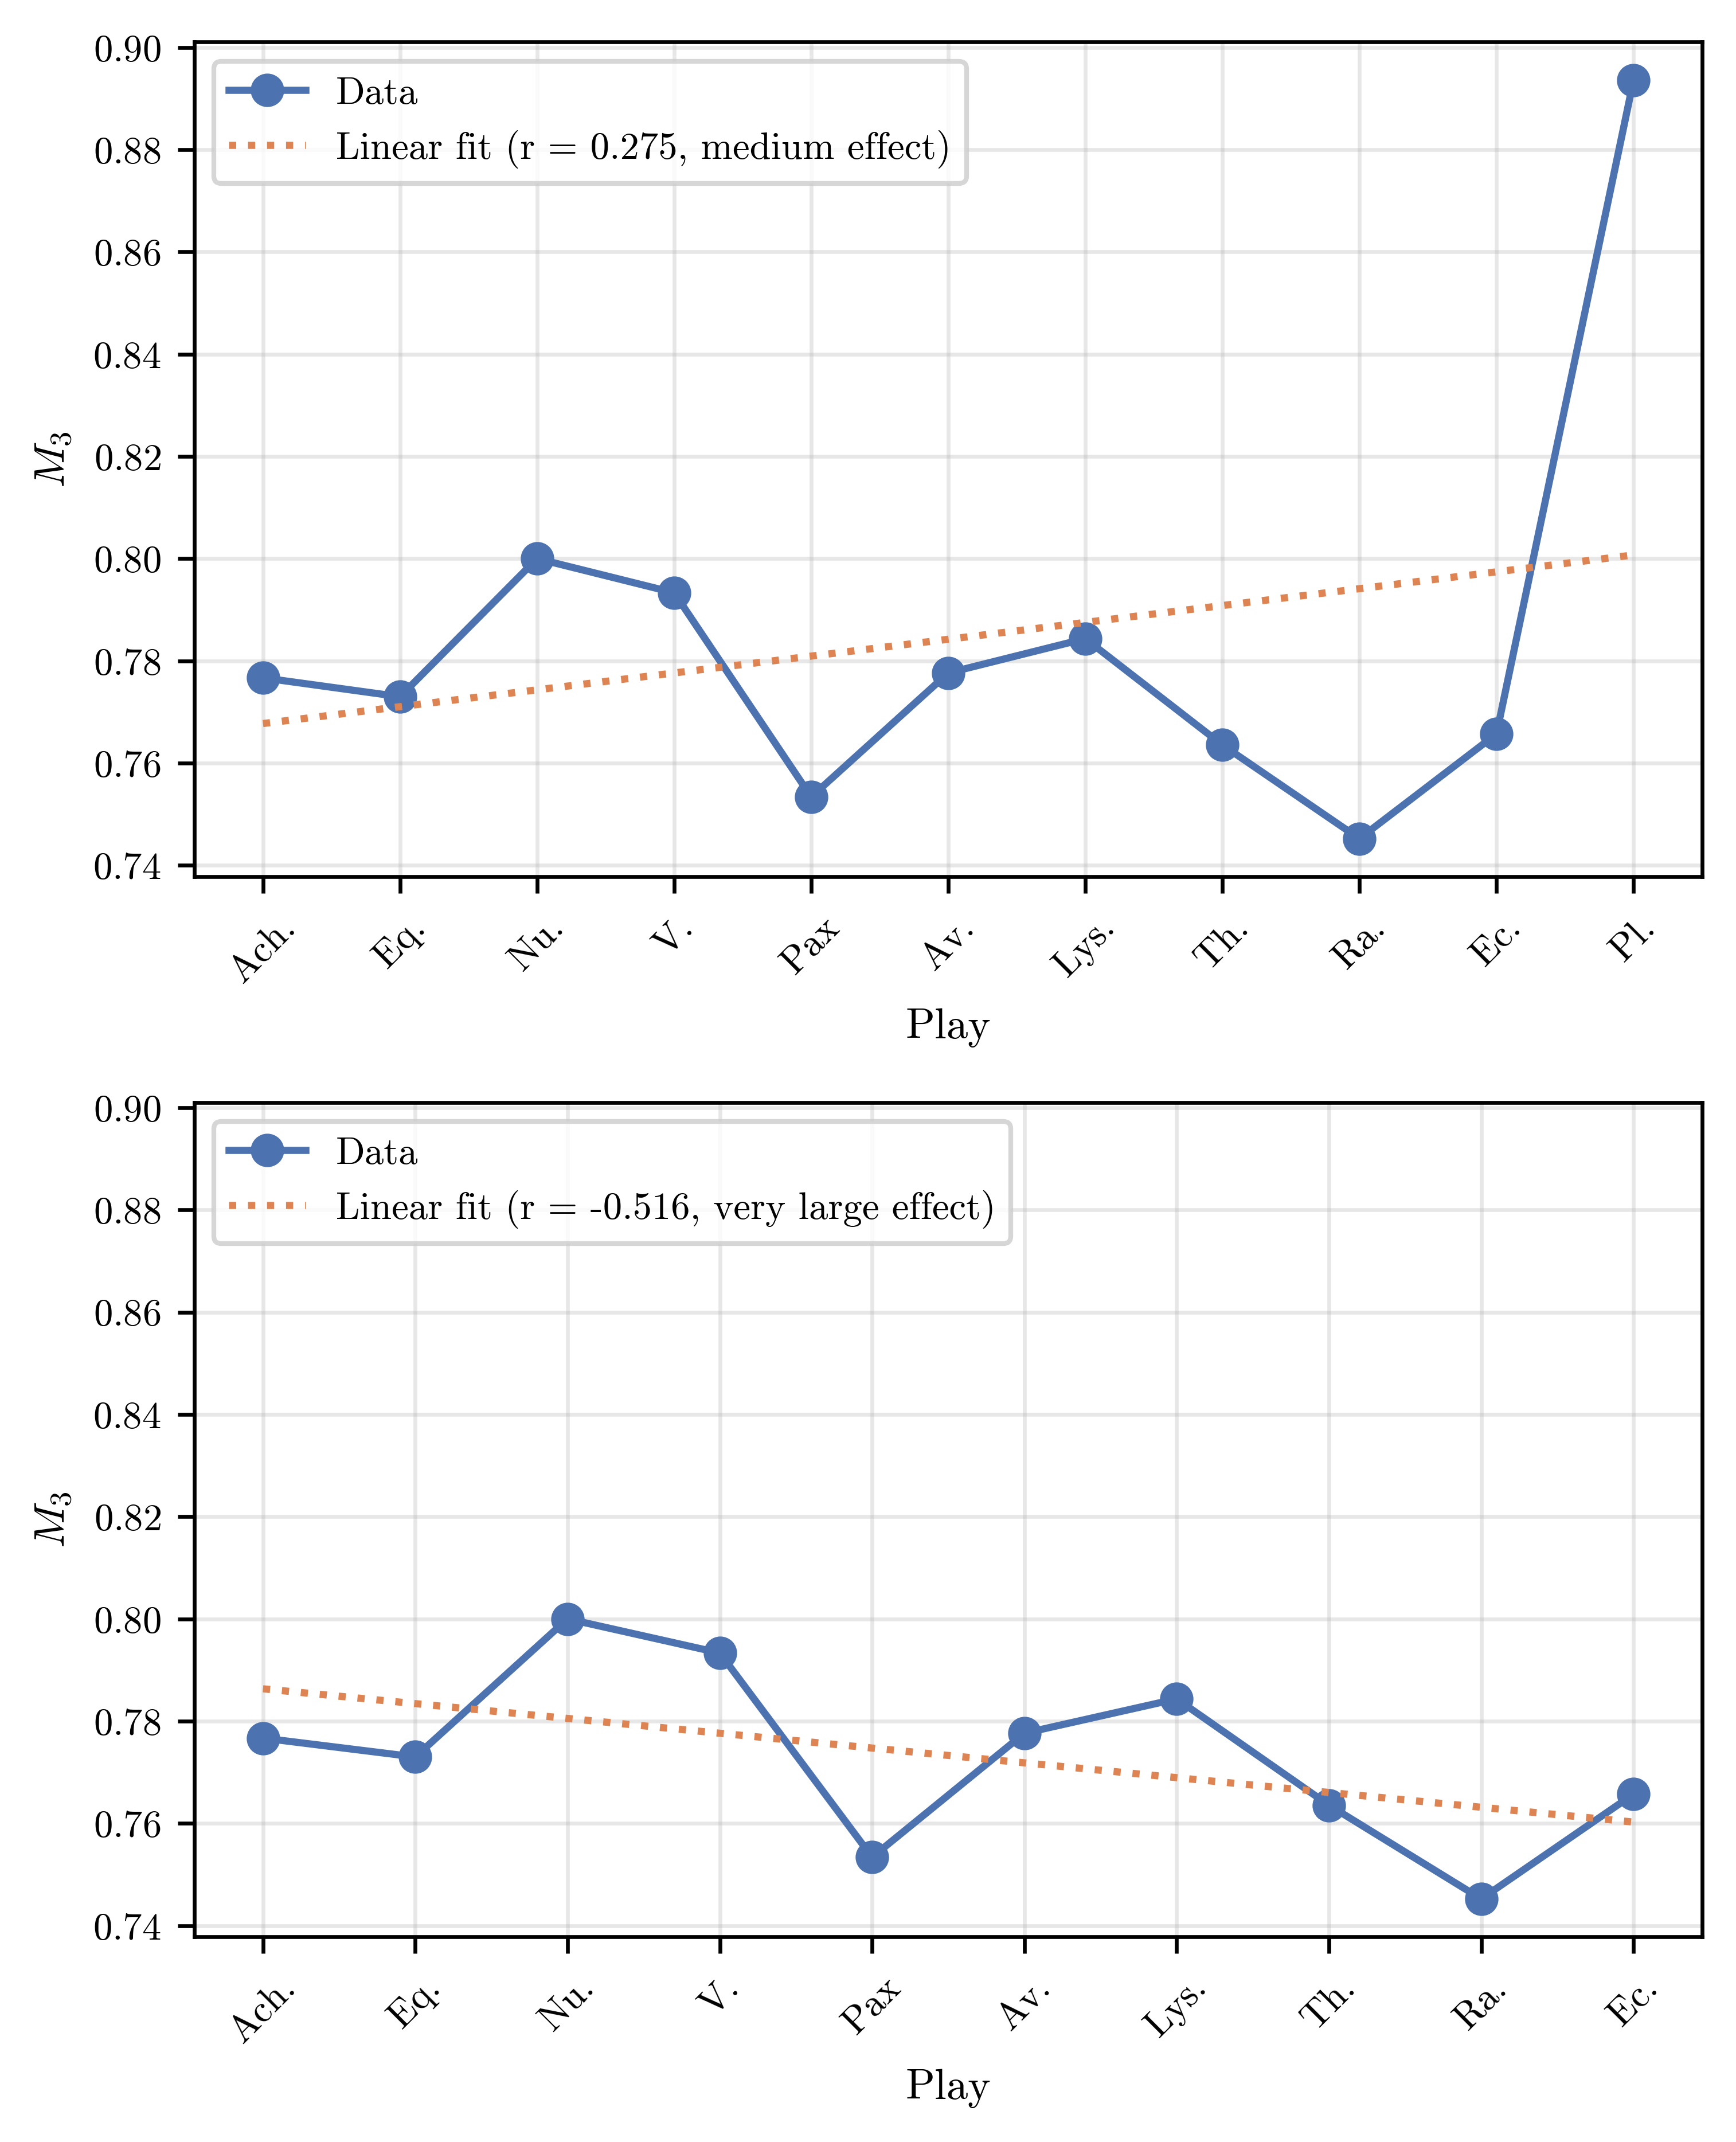

In [12]:
import matplotlib.pyplot as plt
from scipy.stats import linregress
from aristophanis_cantica.plot import apply_plotting_poetry_palette_stacked
from aristophanis_cantica.utils.utils import get_cohen_category, abbreviations_fancy

apply_plotting_poetry_palette_stacked()
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

def plot_regression_on_ax(ax, data, title):
    # Convert keys to numeric x positions
    x = list(range(len(data)))
    labels = [abbreviations_fancy.get(k, k) for k in data]

    # Keep exact values in `data`; convert to float only at regression/plot boundary
    y = [float(v) for v in data.values()]

    # Linear regression
    slope, intercept, r_value, *_ = linregress(x, y)
    regression_line = [slope * xi + intercept for xi in x]

    # Plot
    ax.plot(x, y, marker="o", color=default_colors[0], label="Data")
    ax.plot(
        x,
        regression_line,
        color=default_colors[1],
        linestyle=":",
        label=f"Linear fit (r = {r_value:.3f}, {get_cohen_category(r_value)} effect)",
    )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45)
    ax.set_xlabel("Play")
    ax.set_ylabel("$M_3$")
    #ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left")


# Build datasets
data_with_pl = play_dict
data_without_pl = {k: v for k, v in play_dict.items() if k != "pl"}

# Single figure with two subplots
fig, axes = plt.subplots(
    2, 1,
    sharey=True
)

plot_regression_on_ax(
    axes[0],
    data_with_pl,
    "Linear Regression of Play Compatibility",
)
plot_regression_on_ax(
    axes[1],
    data_without_pl,
    "Linear Regression of Play Compatibility (Excl. Plutus)",
)

plt.tight_layout()
plt.savefig(ROOT / "media/play_regression/linreg_comp.png", dpi=600)
plt.show()

Let's do it for Conser's Aeschylus:

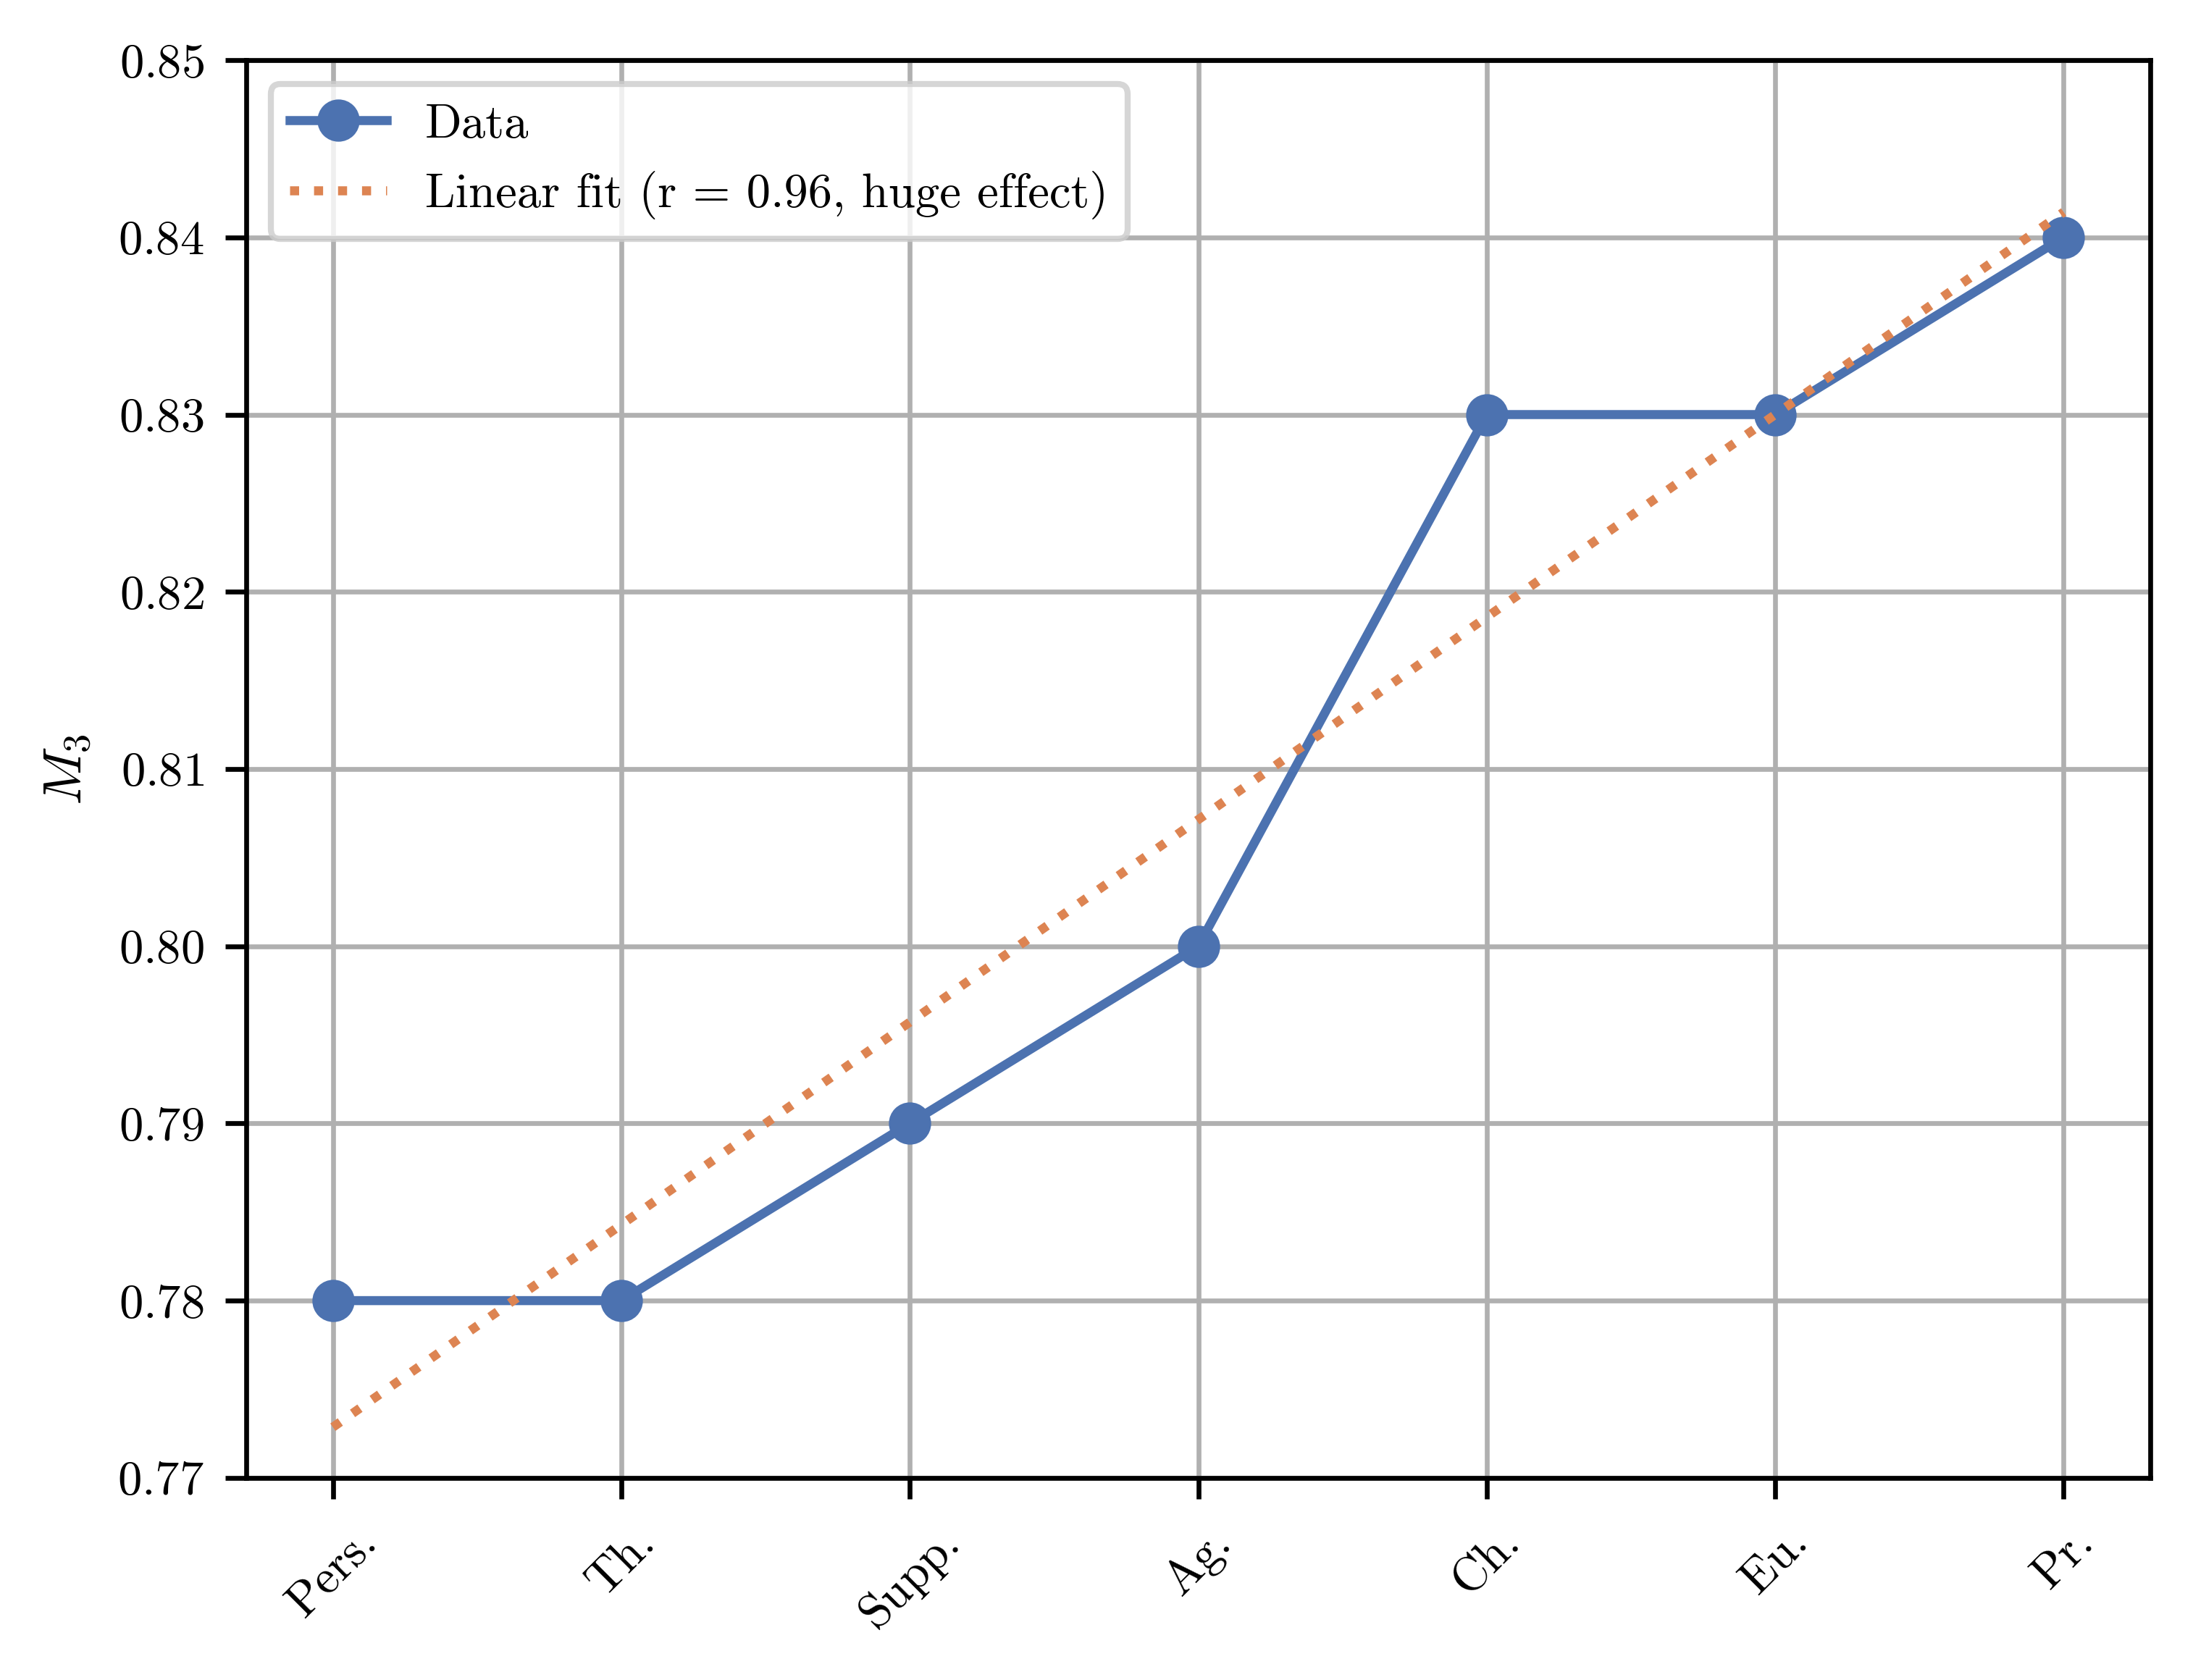

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress
from aristophanis_cantica.plot import apply_plotting_poetry_palette
from aristophanis_cantica.utils.utils import get_cohen_category

apply_plotting_poetry_palette()
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Data
plays_ae = [
    "Pers.",
    "Th.",
    "Supp.",
    "Ag.",
    "Ch.",
    "Eu.",
    "Pr.",
]
compatibility_means = [0.78, 0.78, 0.79, 0.80, 0.83, 0.83, 0.84]

# Numeric x-values for regression
x_numeric = np.arange(len(plays_ae))
y = np.array(compatibility_means)

# Linear regression
slope, intercept, r_value, p_value, std_err = linregress(x_numeric, y)
regression_line = slope * x_numeric + intercept

r_interpretation = get_cohen_category(r_value)

# Plotting
plt.figure()
plt.plot(plays_ae, compatibility_means, marker='o', color=default_colors[0], label="Data")
plt.plot(plays_ae, regression_line, color=default_colors[1], linestyle=':', label=f"Linear fit (r = {r_value:.2f}, {r_interpretation} effect)")
plt.xticks(rotation=45)
plt.ylabel("$M_3$")
#plt.title("Comparison: Significant Linear Regression of Play Compatibility for Conser's Aeschylus")
plt.ylim(0.77, 0.85)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(ROOT / 'media/play_regression/linreg_aeschylus.png', dpi=600)
plt.show()

## Comparison Aristophanes-Aeschylus

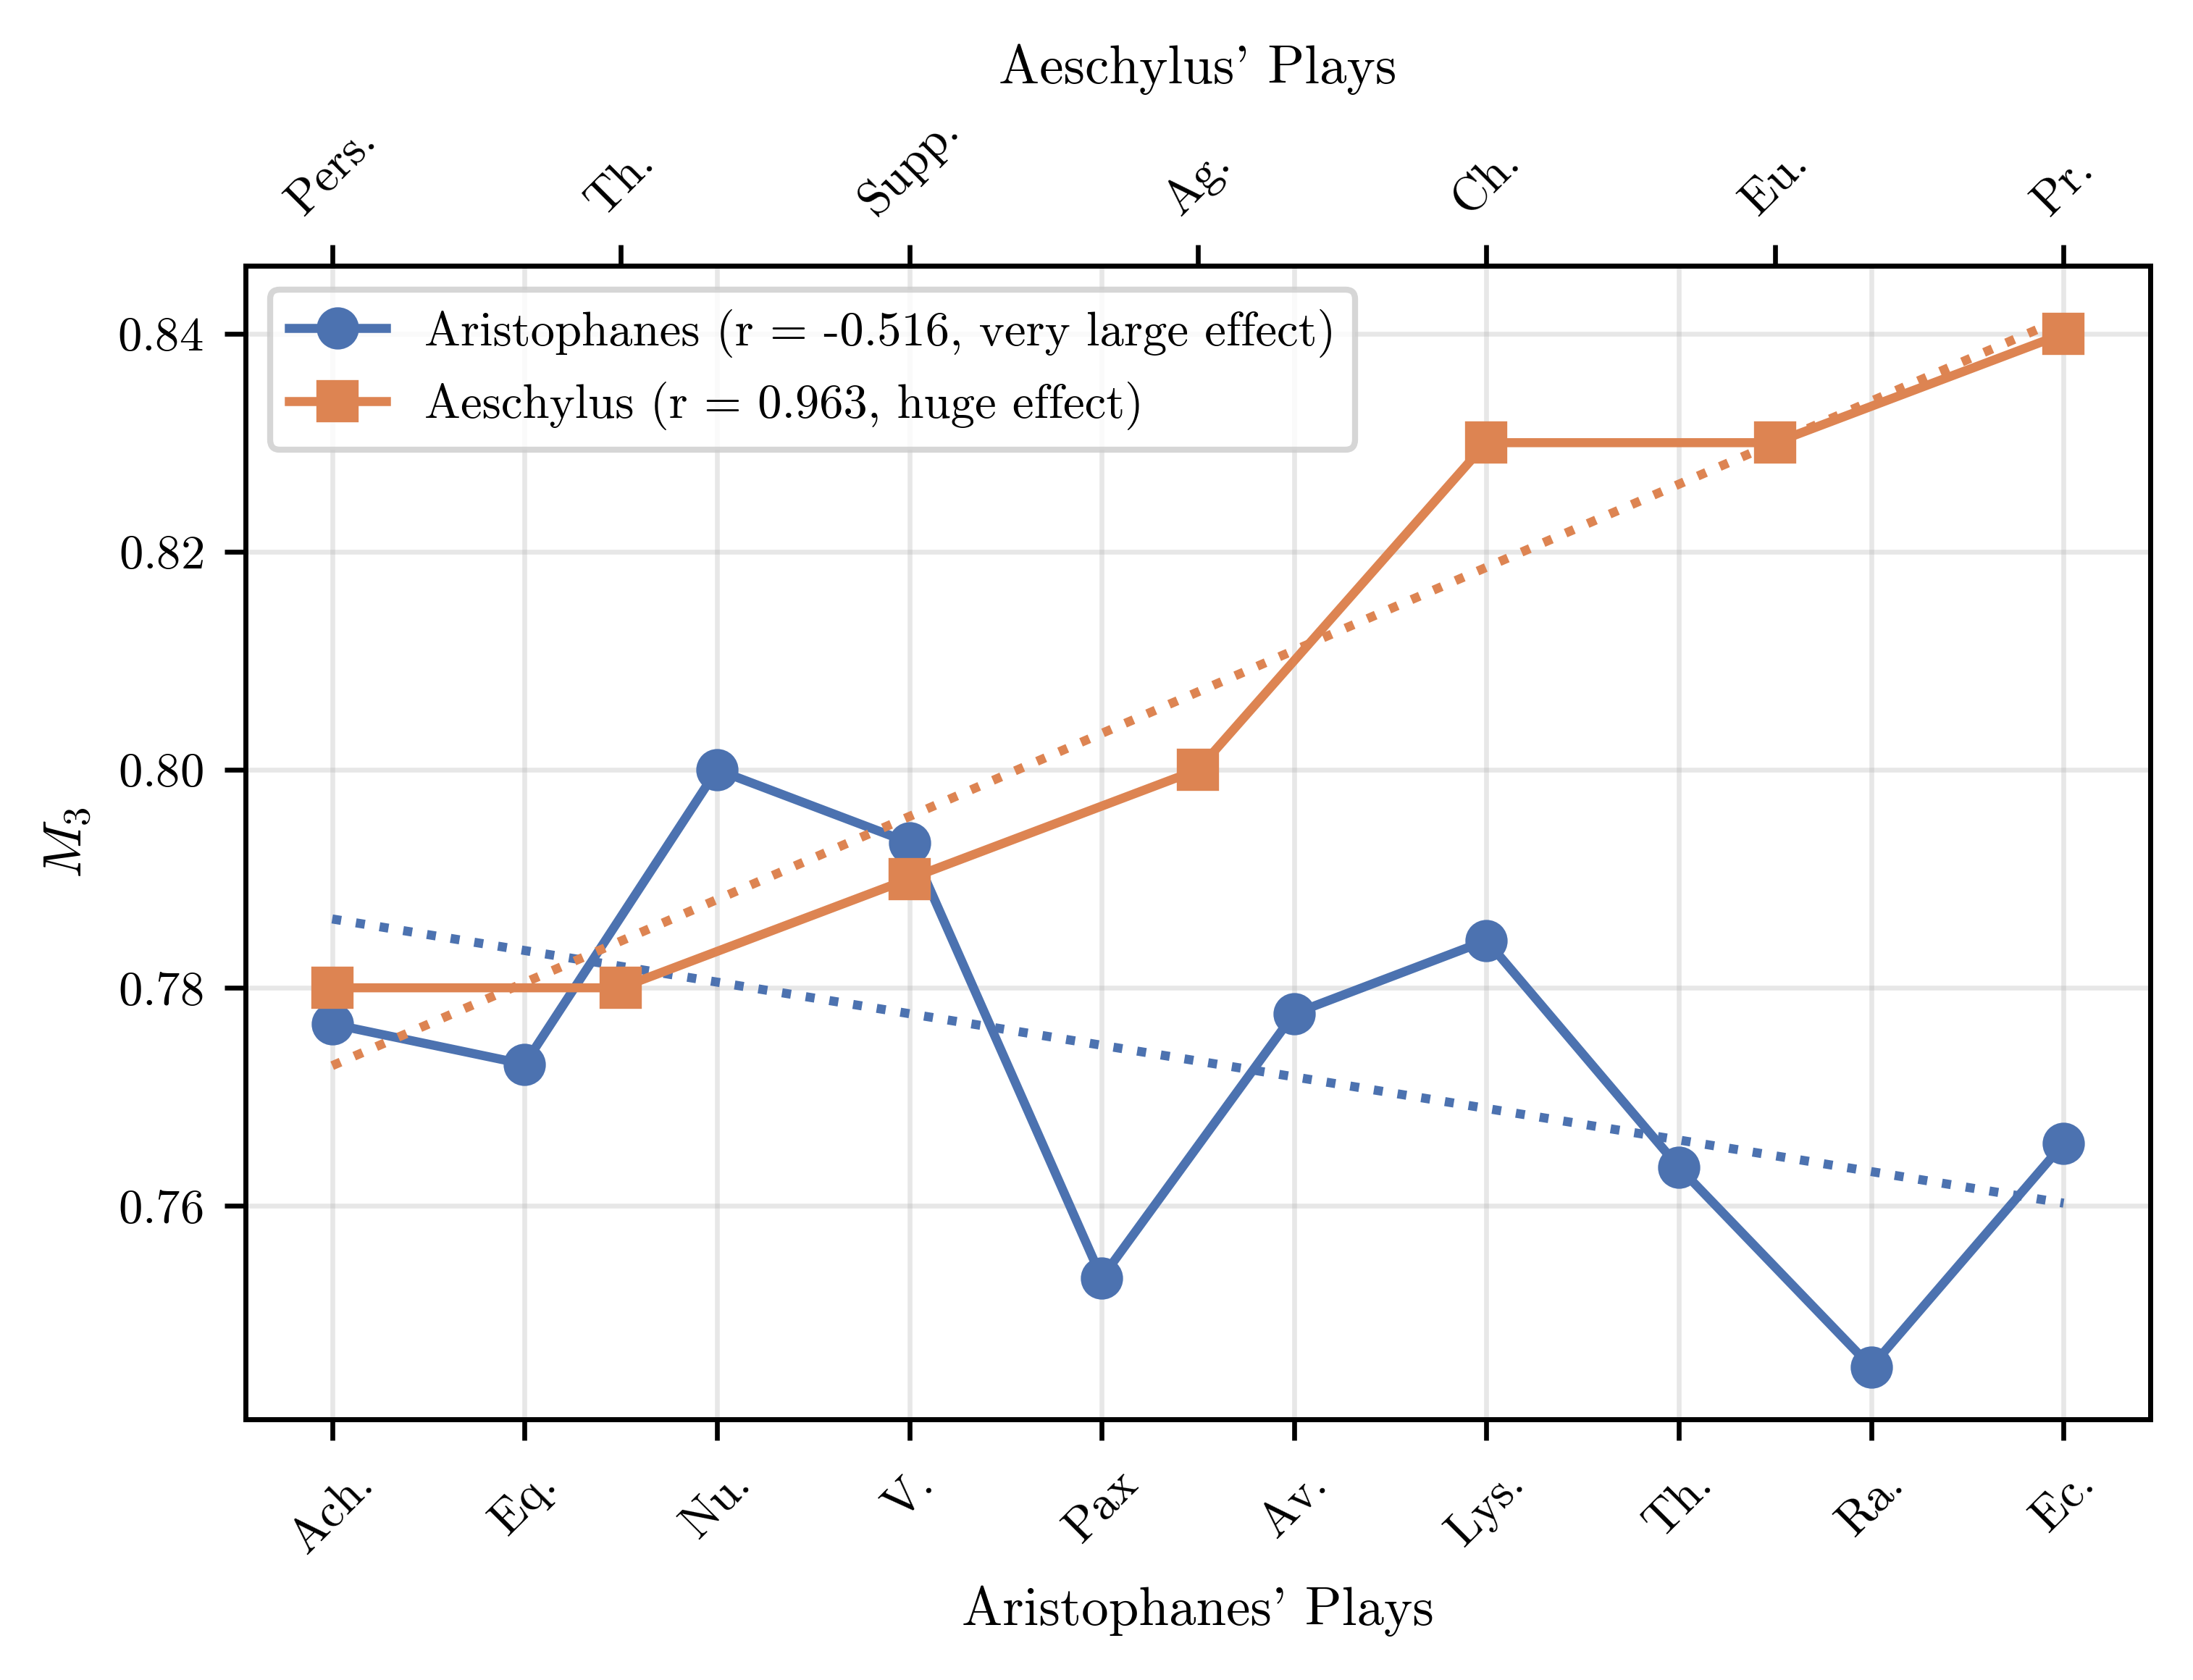

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

from aristophanis_cantica.plot import apply_plotting_poetry_palette
from aristophanis_cantica.utils.utils import get_cohen_category, abbreviations_fancy

apply_plotting_poetry_palette()
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

# ====================================
# Aristophanes (bottom x-axis)
# ====================================
data_without_pl = {
    k: v
    for k, v in play_dict.items()
    if k != "pl"
}

x_ar = np.arange(len(data_without_pl), dtype=float)
labels_ar = [abbreviations_fancy.get(k, k) for k in data_without_pl.keys()]
y_ar = np.array(
    [float(v) for v in data_without_pl.values()],
    dtype=float,
)

slope_ar, intercept_ar, r_ar, _, _ = linregress(x_ar, y_ar)
fit_ar = slope_ar * x_ar + intercept_ar


# ====================================
# Aeschylus (top x-axis)
# ====================================
# plays_ae = [
#     "Persae",
#     "Septem",
#     "Supplices",
#     "Agamemnon",
#     "Choephori",
#     "Eumenides",
#     "Prometheus",
# ]
plays_ae = [
    "Pers.",
    "Th.",
    "Supp.",
    "Ag.",
    "Ch.",
    "Eu.",
    "Pr.",
]

y_ae = np.array(
    [0.78, 0.78, 0.79, 0.80, 0.83, 0.83, 0.84],
    dtype=float,
)

# Spread Aeschylus plays across same horizontal span
x_ae = np.linspace(0, len(x_ar) - 1, len(plays_ae))

slope_ae, intercept_ae, r_ae, _, _ = linregress(x_ae, y_ae)
fit_ae = slope_ae * x_ae + intercept_ae


# ====================================
# Single figure
# ====================================
fig, ax = plt.subplots()

# Aristophanes
ax.plot(
    x_ar,
    y_ar,
    marker="o",
    color=default_colors[0],
    label=f"Aristophanes (r = {r_ar:.3f}, {get_cohen_category(r_ar)} effect)",
)

ax.plot(
    x_ar,
    fit_ar,
    color=default_colors[0],
    linestyle=":",
)

# Aeschylus
ax.plot(
    x_ae,
    y_ae,
    marker="s",
    color=default_colors[1],
    label=f"Aeschylus (r = {r_ae:.3f}, {get_cohen_category(r_ae)} effect)",
)

ax.plot(
    x_ae,
    fit_ae,
    color=default_colors[1],
    linestyle=":",
)

# Bottom x-axis
ax.set_xticks(x_ar)
ax.set_xticklabels(labels_ar, rotation=45)
ax.set_xlabel("Aristophanes' Plays")

# Top x-axis
ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())
ax_top.set_xticks(x_ae)
ax_top.set_xticklabels(plays_ae, rotation=45)
ax_top.set_xlabel("Aeschylus' Plays")

# Y-axis
ax.set_ylabel("$M_3$")

# Style
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left")

plt.tight_layout()
plt.savefig(
    ROOT / "media/play_regression/linreg_aeschylus_aristophanes.png",
    dpi=600,
)
plt.show()

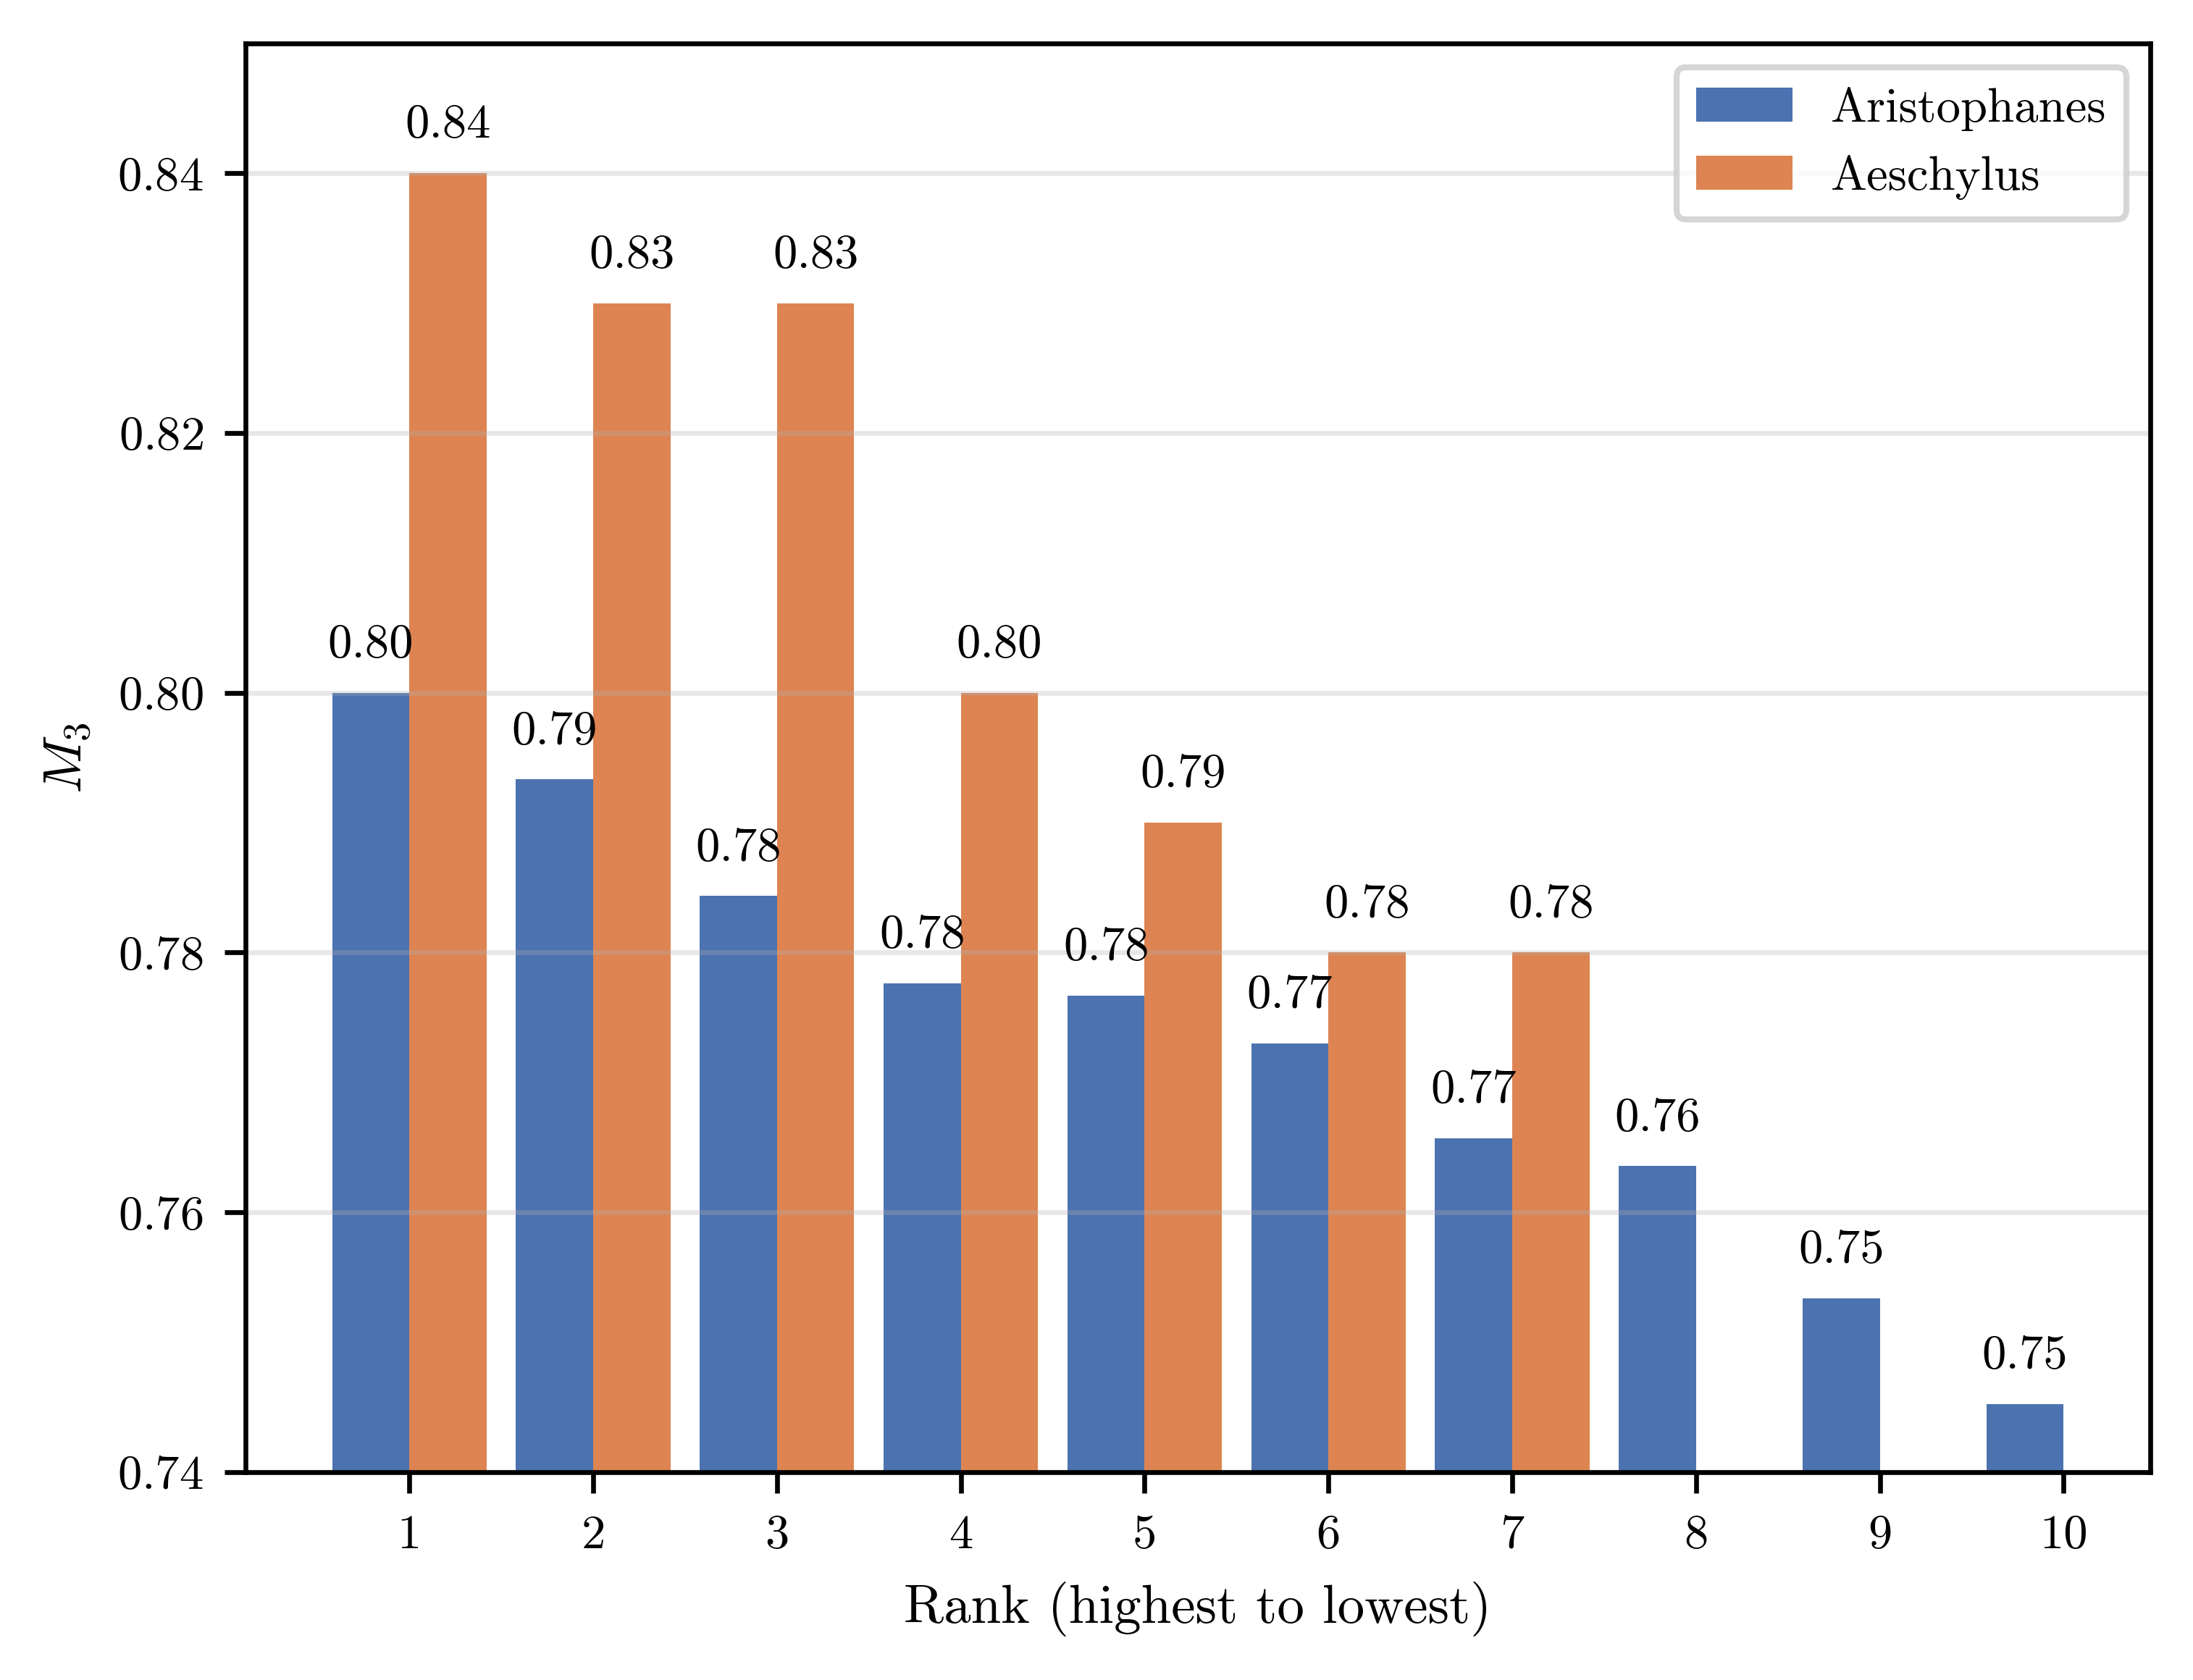

In [19]:
import matplotlib.pyplot as plt
import numpy as np

from aristophanis_cantica.plot import apply_plotting_poetry_palette
from aristophanis_cantica.utils.utils import abbreviations_fancy

apply_plotting_poetry_palette()
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

# ====================================
# Aristophanes data
# ====================================
data_without_pl = {
    k: v
    for k, v in play_dict.items()
    if k != "pl"
}

labels_ar = [abbreviations_fancy.get(k, k) for k in data_without_pl.keys()]
y_ar = np.array(
    [float(v) for v in data_without_pl.values()],
    dtype=float,
)

# CHANGED: sort Aristophanes descending by value
order_ar = np.argsort(y_ar)[::-1]
y_ar = y_ar[order_ar]
labels_ar = [labels_ar[i] for i in order_ar]

# ====================================
# Aeschylus data
# ====================================
plays_ae = [
    "Pers.",
    "Th.",
    "Supp.",
    "Ag.",
    "Ch.",
    "Eu.",
    "Pr.",
]

y_ae = np.array(
    [0.78, 0.78, 0.79, 0.80, 0.83, 0.83, 0.84],
    dtype=float,
)

# CHANGED: sort Aeschylus descending by value
order_ae = np.argsort(y_ae)[::-1]
y_ae = y_ae[order_ae]
plays_ae = [plays_ae[i] for i in order_ae]

# ====================================
# Build paired bar positions
# ====================================
# CHANGED: use longest dataset as master x-axis
n_ar = len(y_ar)
n_ae = len(y_ae)
n_max = max(n_ar, n_ae)

x = np.arange(n_max)
width = 0.42

fig, ax = plt.subplots()

# CHANGED: Aristophanes always plotted
ax.bar(
    x - width / 2,
    np.pad(y_ar, (0, n_max - n_ar), constant_values=np.nan),
    width=width,
    color=default_colors[0],
    label="Aristophanes",
)

# CHANGED: Aeschylus only where data exists
ax.bar(
    x[:n_ae] + width / 2,
    y_ae,
    width=width,
    color=default_colors[1],
    label="Aeschylus",
)

# ====================================
# Labels
# ====================================
# CHANGED: no play-name x-axis labels, only ranks
ax.set_xticks(x)
ax.set_xticklabels(np.arange(1, n_max + 1))
ax.set_xlabel("Rank (highest to lowest)")
ax.set_ylabel("$M_3$")
ax.set_ylim(0.74, 0.85)

# Optional value labels
for i, v in enumerate(y_ar):
    ax.text(i - width / 2, v + 0.002, f"{v:.2f}", ha="center", va="bottom", fontsize=8)

for i, v in enumerate(y_ae):
    ax.text(i + width / 2, v + 0.002, f"{v:.2f}", ha="center", va="bottom", fontsize=8)

# ====================================
# Style
# ====================================
ax.grid(True, axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig(
    ROOT / "media/play_regression/histogram_aeschylus_aristophanes.png",
    dpi=600,
)
plt.show()